In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Dermal toxicity\dataset\test_set_acute_dermal_features.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.3315345571001684, -0.04386761694440085, 0....  497   
1  [-0.4567077543031368, 0.024564669463881604, 0....  245   
2  [0.5742766649415614, 1.461928059334721, 1.5534...  554   
3  [-1.47717546146

In [3]:
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0.0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3315345571001684, -0.04386761694440085, 0....",497,CCSC(=O)N(CC)C1CCCCC1,215.134385292,3.5141000000000027,91.42730681387879,20.310000000000002,...,0.0,2.0,7.0,0.5,5.0,0.0,45.61000000000001,4.807354922057604,2.9770000000000003,0.9090909090909092
1,1.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4567077543031368, 0.024564669463881604, 0....",245,CNCC(O)c1ccc(O)c(O)c1,183.089543276,0.35060000000000013,76.45879290288288,72.72,...,4.0,2.0,5.0,0.5,3.0,0.0,72.72,4.700439718141093,0.2769999999999999,0.3333333333333333
2,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5742766649415614, 1.461928059334721, 1.5534...",554,CC1CC(=O)C=C2CCC3C4CCC(O)C4(C)CCC3C21C,302.2245802,4.125200000000003,133.9159794073037,37.3,...,1.0,0.0,0.0,0.5,0.0,0.0,37.3,5.643856189774724,4.143000000000001,0.85
3,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.47717546146107, -2.570136502520576, -2.662...",213,CN(C)N,60.06874825599999,-0.5783,26.17405352967722,29.259999999999998,...,1.0,0.0,3.0,0.5,0.0,0.0,29.26,2.584962500721156,-1.3850000000000002,1.0
4,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6554648812512847, -0.2906280764936018, -0....",535,CC1OC(C)OC(C)OC(C)O1,176.104858992,1.4504,72.7421955931041,36.92,...,0.0,0.0,0.0,0.3333333333333333,0.0,0.0,36.92,4.584962500721156,1.628,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.30999216218504383, 0.40113156690460006, 0....",351,CNC(=O)N(C)c1nnc(C(F)(F)F)s1,240.029266504,1.3325,86.9071085404265,58.120000000000005,...,1.0,0.0,5.0,0.5,4.0,0.0,86.36,4.906890595608519,1.267,0.5
122,0.0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5327145539700302, 1.1163800130206543, 0.953...",321,CC1(C)CCC(=Cc2ccc(Cl)cc2)C1(O)Cn1cncn1,317.12948994000004,3.566200000000003,135.00192358640206,50.94,...,1.0,0.0,0.0,0.4545454545454545,3.0,0.0,50.94,5.584962500721157,2.6340000000000003,0.4117647058823529
123,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0424744430639628, -0.9014838098127014, -0....",219,Sc1ccccc1,110.019021192,1.9752999999999996,48.58646978289869,0.0,...,0.0,0.0,0.0,0.25,0.0,0.0,38.8,3.807354922057604,2.4000000000000004,0.0
124,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.34512390148573613, 0.06636121387665492, 0.1...",410,COc1cc(OC)nc(NC(=O)Oc2ccccc2)n1,275.09060589600006,2.1047,115.07463960281629,82.57000000000001,...,1.0,0.0,3.0,0.4545454545454545,6.0,0.0,82.57000000000001,5.392317422778761,2.734000000000001,0.1538461538461538


In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


Classes                          :  ['0.0' '1.0']
Number of cpds in each class     :  [57, 69]
Total number of cpds             :  126
Class mapping:  {0: 0, 1: 1}


In [5]:
print(test_df['Outcome'].value_counts())

Outcome
1.0    69
0.0    57
Name: count, dtype: int64


{0: 0, 1: 1}

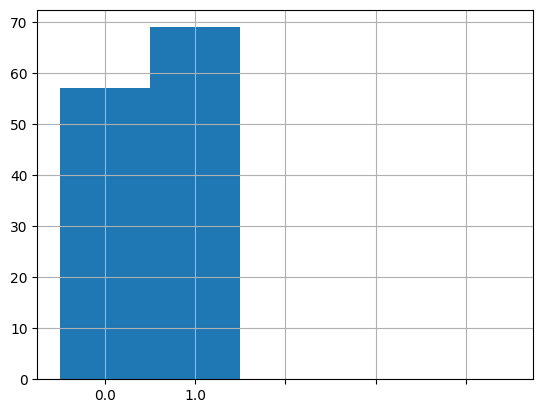

In [6]:
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [7]:
import joblib
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_morgan.pkl')  
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_RF_modred.pkl')

svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_XGB_modred.pkl')

gpc_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_GPC_morgan.pkl')  
gpc_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_GPC_maccskey.pkl')
gpc_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_GPC_modred.pkl')

nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_LGBM_modred.pkl')

cbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_CBM_morgan.pkl')  
cbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_CBM_maccskey.pkl')
cbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Dermal toxicity/model - pribadi/fingerprint descriptor (model)/Model_Dermal_toxicity_CBM_modred.pkl')


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


In [10]:
y_true = test_df['Outcome'].astype(float).astype(int)


In [11]:
# Consensus with probability average 

def predict_with_models_probabilities(moldf):
    # Assuming `predict_proba` method is available and returns probabilities for the positive class
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
   # mean_probs = np.mean([morgan_probs, maccs_probs], axis=0)
   # mean_probs = np.mean([maccs_probs, modred_probs], axis=0)
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])

                                     SMILES  Predictions
0                     CCSC(=O)N(CC)C1CCCCC1            0
1                     CNCC(O)c1ccc(O)c(O)c1            0
2    CC1CC(=O)C=C2CCC3C4CCC(O)C4(C)CCC3C21C            0
3                                    CN(C)N            1
4                      CC1OC(C)OC(C)OC(C)O1            1
..                                      ...          ...
121            CNC(=O)N(C)c1nnc(C(F)(F)F)s1            0
122  CC1(C)CCC(=Cc2ccc(Cl)cc2)C1(O)Cn1cncn1            0
123                               Sc1ccccc1            1
124         COc1cc(OC)nc(NC(=O)Oc2ccccc2)n1            0
125                    COc1cc(C(F)(F)F)ccn1            0

[126 rows x 2 columns]


In [12]:
def predict_with_models_probabilities(test_df):
 
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs

# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs



from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)


auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary') 
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[41 16]
 [21 48]]
Accuracy: 0.7063492063492064
AUC Score: 0.8307907449783881
F1 Score: 0.7218045112781954
Sensitivity: 0.6956521739130435
Specificity: 0.7192982456140351
CCR (Correct Classification Rate): 0.7074752097635393
PPV (Positive Predictive Value): 0.75
NPV (Negative Predictive Value): 0.6612903225806451


In [13]:
#3 kolom include smiles, prediction and mean prob 

def predict_with_models_probabilities(test_df):
    # Assuming `predict_proba` method is available and returns probabilities for the positive class
    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Calculate the mean probability across all models
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    
    # Convert mean probabilities to final class predictions (e.g., threshold at 0.5)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs

# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

# Replace 'Your_Actual_Labels_Column_Name' with the correct column name for actual labels in your DataFrame
#y_true = test_df['Outcome'].astype(int)  # Convert y_true to integer type

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

# Now you can calculate AUC using mean_probs
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

# Calculate AUC using mean probabilities
auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')  # For binary classification
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp)
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn)
print("NPV (Negative Predictive Value):", npv)


                                     SMILES  Predictions  Mean_Probabilities
0                     CCSC(=O)N(CC)C1CCCCC1            0            0.238333
1                     CNCC(O)c1ccc(O)c(O)c1            0            0.406667
2    CC1CC(=O)C=C2CCC3C4CCC(O)C4(C)CCC3C21C            0            0.340000
3                                    CN(C)N            1            0.771667
4                      CC1OC(C)OC(C)OC(C)O1            1            0.526667
..                                      ...          ...                 ...
121            CNC(=O)N(C)c1nnc(C(F)(F)F)s1            0            0.255000
122  CC1(C)CCC(=Cc2ccc(Cl)cc2)C1(O)Cn1cncn1            0            0.216667
123                               Sc1ccccc1            1            0.851667
124         COc1cc(OC)nc(NC(=O)Oc2ccccc2)n1            0            0.126667
125                    COc1cc(C(F)(F)F)ccn1            0            0.281667

[126 rows x 3 columns]
Confusion Matrix:
[[41 16]
 [21 48]]
Accuracy: 0.706

In [14]:
#RF
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = rf_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = rf_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = rf_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[43 14]
 [18 51]]
Accuracy: 0.746031746031746
AUC Score: 0.8300279684719044
F1 Score: 0.7611940298507462
Sensitivity: 0.7391304347826086
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7467581998474446
PPV (Positive Predictive Value): 0.7846153846153846
NPV (Negative Predictive Value): 0.7049180327868853

MACCS Performance:
Confusion Matrix: [[44 13]
 [24 45]]
Accuracy: 0.7063492063492064
AUC Score: 0.7812102720569539
F1 Score: 0.7086614173228346
Sensitivity: 0.6521739130434783
Specificity: 0.7719298245614035
CCR (Correct Classification Rate): 0.7120518688024409
PPV (Positive Predictive Value): 0.7758620689655172
NPV (Negative Predictive Value): 0.6470588235294118

Modred Performance:
Confusion Matrix: [[46 11]
 [21 48]]
Accuracy: 0.746031746031746
AUC Score: 0.8029494024917365
F1 Score: 0.75
Sensitivity: 0.6956521739130435
Specificity: 0.8070175438596491
CCR (Correct Classification Rate): 0.7513348588863462
PPV (Positive Pred

In [15]:
#SVM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = svm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = svm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = svm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[43 14]
 [17 52]]
Accuracy: 0.753968253968254
AUC Score: 0.8032036613272311
F1 Score: 0.7703703703703704
Sensitivity: 0.7536231884057971
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7540045766590389
PPV (Positive Predictive Value): 0.7878787878787878
NPV (Negative Predictive Value): 0.7166666666666667

MACCS Performance:
Confusion Matrix: [[44 13]
 [19 50]]
Accuracy: 0.746031746031746
AUC Score: 0.792143401983219
F1 Score: 0.7575757575757576
Sensitivity: 0.7246376811594203
Specificity: 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV (Positive Predictive Value): 0.7936507936507936
NPV (Negative Predictive Value): 0.6984126984126984

Modred Performance:
Confusion Matrix: [[43 14]
 [25 44]]
Accuracy: 0.6904761904761905
AUC Score: 0.7718026951436562
F1 Score: 0.6929133858267716
Sensitivity: 0.6376811594202898
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.6960335621662852
PPV (

In [16]:
#XGB
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = xgb_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = xgb_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = xgb_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[43 14]
 [16 53]]
Accuracy: 0.7619047619047619
AUC Score: 0.8095601322145944
F1 Score: 0.7794117647058824
Sensitivity: 0.7681159420289855
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7612509534706331
PPV (Positive Predictive Value): 0.7910447761194029
NPV (Negative Predictive Value): 0.7288135593220338

MACCS Performance:
Confusion Matrix: [[42 15]
 [22 47]]
Accuracy: 0.7063492063492064
AUC Score: 0.7955758962623951
F1 Score: 0.7175572519083969
Sensitivity: 0.6811594202898551
Specificity: 0.7368421052631579
CCR (Correct Classification Rate): 0.7090007627765065
PPV (Positive Predictive Value): 0.7580645161290323
NPV (Negative Predictive Value): 0.65625

Modred Performance:
Confusion Matrix: [[43 14]
 [23 46]]
Accuracy: 0.7063492063492064
AUC Score: 0.7772692601067888
F1 Score: 0.7131782945736435
Sensitivity: 0.6666666666666666
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7105263157894737
PPV (Positive

In [17]:
#NN
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = nn_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = nn_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = nn_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[43 14]
 [20 49]]
Accuracy: 0.7301587301587301
AUC Score: 0.8014238494787694
F1 Score: 0.7424242424242424
Sensitivity: 0.7101449275362319
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7322654462242564
PPV (Positive Predictive Value): 0.7777777777777778
NPV (Negative Predictive Value): 0.6825396825396826

MACCS Performance:
Confusion Matrix: [[41 16]
 [23 46]]
Accuracy: 0.6904761904761905
AUC Score: 0.7681159420289856
F1 Score: 0.7022900763358778
Sensitivity: 0.6666666666666666
Specificity: 0.7192982456140351
CCR (Correct Classification Rate): 0.6929824561403508
PPV (Positive Predictive Value): 0.7419354838709677
NPV (Negative Predictive Value): 0.640625

Modred Performance:
Confusion Matrix: [[39 18]
 [20 49]]
Accuracy: 0.6984126984126984
AUC Score: 0.7679888126112383
F1 Score: 0.7205882352941176
Sensitivity: 0.7101449275362319
Specificity: 0.6842105263157895
CCR (Correct Classification Rate): 0.6971777269260107
PPV (Positiv

In [18]:
#GPC
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = gpc_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = gpc_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = gpc_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[41 16]
 [16 53]]
Accuracy: 0.746031746031746
AUC Score: 0.8126112382405289
F1 Score: 0.7681159420289855
Sensitivity: 0.7681159420289855
Specificity: 0.7192982456140351
CCR (Correct Classification Rate): 0.7437070938215102
PPV (Positive Predictive Value): 0.7681159420289855
NPV (Negative Predictive Value): 0.7192982456140351

MACCS Performance:
Confusion Matrix: [[43 14]
 [21 48]]
Accuracy: 0.7222222222222222
AUC Score: 0.7818459191456902
F1 Score: 0.732824427480916
Sensitivity: 0.6956521739130435
Specificity: 0.7543859649122807
CCR (Correct Classification Rate): 0.7250190694126621
PPV (Positive Predictive Value): 0.7741935483870968
NPV (Negative Predictive Value): 0.671875

Modred Performance:
Confusion Matrix: [[57  0]
 [69  0]]
Accuracy: 0.4523809523809524
AUC Score: 0.7327739638952454
F1 Score: 0.0
Sensitivity: 0.0
Specificity: 1.0
CCR (Correct Classification Rate): 0.5
PPV (Positive Predictive Value): nan
NPV (Negative Predictive Value): 0.45

C:\Users\User\AppData\Local\Temp\ipykernel_22560\2201677702.py:28: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp / (tp + fp)


In [19]:
#LGBM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = lgbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = lgbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = lgbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[40 17]
 [23 46]]
Accuracy: 0.6825396825396826
AUC Score: 0.7570556826849733
F1 Score: 0.696969696969697
Sensitivity: 0.6666666666666666
Specificity: 0.7017543859649122
CCR (Correct Classification Rate): 0.6842105263157894
PPV (Positive Predictive Value): 0.7301587301587301
NPV (Negative Predictive Value): 0.6349206349206349

MACCS Performance:
Confusion Matrix: [[45 12]
 [21 48]]
Accuracy: 0.7380952380952381
AUC Score: 0.8023137554030002
F1 Score: 0.7441860465116279
Sensitivity: 0.6956521739130435
Specificity: 0.7894736842105263
CCR (Correct Classification Rate): 0.7425629290617849
PPV (Positive Predictive Value): 0.8
NPV (Negative Predictive Value): 0.6818181818181818

Modred Performance:
Confusion Matrix: [[46 11]
 [21 48]]
Accuracy: 0.746031746031746
AUC Score: 0.8077803203661328
F1 Score: 0.75
Sensitivity: 0.6956521739130435
Specificity: 0.8070175438596491
CCR (Correct Classification Rate): 0.7513348588863462
PPV (Positive Predictive Value): 

In [20]:
#CBM
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_models_probabilities(test_df):

    morgan_probs = cbm_morgan.predict_proba(np.array(list(test_df['Morgan_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    maccs_probs = cbm_maccs.predict_proba(np.array(list(test_df['MACCS_Descriptors'].values)))[:, 1]  # Probabilities for class 1
    modred_probs = cbm_modred.predict_proba(np.array(list(test_df['Modred_Descriptor'].values)))[:, 1]  # Probabilities for class 1

    # Convert probabilities to final class predictions (e.g., threshold at 0.5)
    morgan_predictions = (morgan_probs > 0.5).astype(int)
    maccs_predictions = (maccs_probs > 0.5).astype(int)
    modred_predictions = (modred_probs > 0.5).astype(int)
    
    return morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs

def evaluate_performance(y_true, predictions, probabilities):
    conf_matrix = confusion_matrix(y_true, predictions)
    accuracy = accuracy_score(y_true, predictions)
    auc_score = roc_auc_score(y_true, probabilities) 
    f1 = f1_score(y_true, predictions, average='binary')  

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ccr = (sensitivity + specificity) / 2
    ppv = tp / (tp + fp)
    npv = tn / (tn + fn)

    return {
        "Confusion Matrix": conf_matrix,
        "Accuracy": accuracy,
        "AUC Score": auc_score,
        "F1 Score": f1,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR (Correct Classification Rate)": ccr,
        "PPV (Positive Predictive Value)": ppv,
        "NPV (Negative Predictive Value)": npv
    }

# Run prediction
morgan_predictions, morgan_probs, maccs_predictions, maccs_probs, modred_predictions, modred_probs = predict_with_models_probabilities(test_df)


morgan_performance = evaluate_performance(y_true, morgan_predictions, morgan_probs)
maccs_performance = evaluate_performance(y_true, maccs_predictions, maccs_probs)
modred_performance = evaluate_performance(y_true, modred_predictions, modred_probs)

# Print performance for each model
print("Morgan Performance:")
for metric, value in morgan_performance.items():
    print(f"{metric}: {value}")

print("\nMACCS Performance:")
for metric, value in maccs_performance.items():
    print(f"{metric}: {value}")

print("\nModred Performance:")
for metric, value in modred_performance.items():
    print(f"{metric}: {value}")


Morgan Performance:
Confusion Matrix: [[41 16]
 [13 56]]
Accuracy: 0.7698412698412699
AUC Score: 0.8449021103483345
F1 Score: 0.7943262411347518
Sensitivity: 0.8115942028985508
Specificity: 0.7192982456140351
CCR (Correct Classification Rate): 0.7654462242562929
PPV (Positive Predictive Value): 0.7777777777777778
NPV (Negative Predictive Value): 0.7592592592592593

MACCS Performance:
Confusion Matrix: [[44 13]
 [19 50]]
Accuracy: 0.746031746031746
AUC Score: 0.8085430968726164
F1 Score: 0.7575757575757576
Sensitivity: 0.7246376811594203
Specificity: 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV (Positive Predictive Value): 0.7936507936507936
NPV (Negative Predictive Value): 0.6984126984126984

Modred Performance:
Confusion Matrix: [[44 13]
 [19 50]]
Accuracy: 0.746031746031746
AUC Score: 0.8082888380371217
F1 Score: 0.7575757575757576
Sensitivity: 0.7246376811594203
Specificity: 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV 

In [22]:
#Persiapan Consensus Deskriptor untuk masing-masing algoritma

import numpy as np
import pandas as pd
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score, 
                             f1_score, precision_score)

X_morgan = np.vstack(test_df['Morgan_Descriptors'].values)
X_maccs  = np.vstack(test_df['MACCS_Descriptors'].values)
X_modred = np.vstack(test_df['Modred_Descriptor'].values)
y_true = test_df['Outcome'].astype(float).astype(int)

# Fungsi Evaluasi 
def print_consensus_result(algo_name, prob_morgan, prob_maccs, prob_modred, y_true):
    # Hitung Rata-rata Probabilitas (Consensus)
    mean_probs = np.mean([prob_morgan, prob_maccs, prob_modred], axis=0)
    # Threshold
    final_preds = (mean_probs > 0.5).astype(int)
    # Metrik
    cm = confusion_matrix(y_true, final_preds)
    tn, fp, fn, tp = cm.ravel()
    
    acc  = accuracy_score(y_true, final_preds)
    auc  = roc_auc_score(y_true, mean_probs)
    f1   = f1_score(y_true, final_preds)
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv  = precision_score(y_true, final_preds, zero_division=0)
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    ccr  = (sens + spec) / 2
    
    print(f"Accuracy                         : {acc}")
    print(f"AUC Score                        : {auc}")
    print(f"F1 Score                         : {f1}")
    print(f"Sensitivity                      : {sens}")
    print(f"Specificity                      : {spec}")
    print(f"CCR (Correct Classification Rate): {ccr}")
    print(f"PPV (Positive Predictive Value)  : {ppv}")
    print(f"NPV (Negative Predictive Value)  : {npv}")

In [23]:
# Random Forest

#Load
prob_rf_morgan = rf_morgan.predict_proba(X_morgan)[:, 1]
prob_rf_maccs  = rf_maccs.predict_proba(X_maccs)[:, 1]
prob_rf_modred = rf_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("Random Forest", prob_rf_morgan, prob_rf_maccs, prob_rf_modred, y_true)

Accuracy                         : 0.7063492063492064
AUC Score                        : 0.8307907449783881
F1 Score                         : 0.7218045112781954
Sensitivity                      : 0.6956521739130435
Specificity                      : 0.7192982456140351
CCR (Correct Classification Rate): 0.7074752097635393
PPV (Positive Predictive Value)  : 0.75
NPV (Negative Predictive Value)  : 0.6612903225806451


In [24]:
# SVM

# Helper function SVM - SVC
def get_svm_proba(model, X):
    try:
        return model.predict_proba(X)[:, 1]
    except AttributeError:
        # Jika probability=False , gunakan decision_function + sigmoid utk parameter
        d = model.decision_function(X)
        return 1 / (1 + np.exp(-d))

# load
prob_svm_morgan = get_svm_proba(svm_morgan, X_morgan)
prob_svm_maccs  = get_svm_proba(svm_maccs, X_maccs)
prob_svm_modred = get_svm_proba(svm_modred, X_modred)

# print
print_consensus_result("SVM", prob_svm_morgan, prob_svm_maccs, prob_svm_modred, y_true)

Accuracy                         : 0.7380952380952381
AUC Score                        : 0.8131197559115179
F1 Score                         : 0.7555555555555555
Sensitivity                      : 0.7391304347826086
Specificity                      : 0.7368421052631579
CCR (Correct Classification Rate): 0.7379862700228832
PPV (Positive Predictive Value)  : 0.7727272727272727
NPV (Negative Predictive Value)  : 0.7


In [25]:
# XGBoosT

#load
prob_xgb_morgan = xgb_morgan.predict_proba(X_morgan)[:, 1]
prob_xgb_maccs  = xgb_maccs.predict_proba(X_maccs)[:, 1]
prob_xgb_modred = xgb_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("XGBoost", prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred, y_true)

Accuracy                         : 0.7301587301587301
AUC Score                        : 0.8151538265954742
F1 Score                         : 0.7424242424242424
Sensitivity                      : 0.7101449275362319
Specificity                      : 0.7543859649122807
CCR (Correct Classification Rate): 0.7322654462242564
PPV (Positive Predictive Value)  : 0.7777777777777778
NPV (Negative Predictive Value)  : 0.6825396825396826


In [26]:
# Neural Network

# load
prob_nn_morgan = nn_morgan.predict_proba(X_morgan)[:, 1]
prob_nn_maccs  = nn_maccs.predict_proba(X_maccs)[:, 1]
prob_nn_modred = nn_modred.predict_proba(X_modred)[:, 1]

# print
print_consensus_result("Neural Network", prob_nn_morgan, prob_nn_maccs, prob_nn_modred, y_true)

Accuracy                         : 0.7222222222222222
AUC Score                        : 0.8009153318077803
F1 Score                         : 0.732824427480916
Sensitivity                      : 0.6956521739130435
Specificity                      : 0.7543859649122807
CCR (Correct Classification Rate): 0.7250190694126621
PPV (Positive Predictive Value)  : 0.7741935483870968
NPV (Negative Predictive Value)  : 0.671875


In [27]:
# GPC

# load
prob_gpc_morgan = gpc_morgan.predict_proba(X_morgan)[:, 1]
prob_gpc_maccs  = gpc_maccs.predict_proba(X_maccs)[:, 1]
prob_gpc_modred = gpc_modred.predict_proba(X_modred)[:, 1]

# print
print_consensus_result("GPC", prob_gpc_morgan, prob_gpc_maccs, prob_gpc_modred, y_true)

Accuracy                         : 0.7301587301587301
AUC Score                        : 0.8047292143401983
F1 Score                         : 0.746268656716418
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7368421052631579
CCR (Correct Classification Rate): 0.7307398932112891
PPV (Positive Predictive Value)  : 0.7692307692307693
NPV (Negative Predictive Value)  : 0.6885245901639344


In [28]:
# LGBM

#load
prob_lgbm_morgan = lgbm_morgan.predict_proba(X_morgan)[:, 1]
prob_lgbm_maccs  = lgbm_maccs.predict_proba(X_maccs)[:, 1]
prob_lgbm_modred = lgbm_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("LGBM", prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred, y_true)

Accuracy                         : 0.7380952380952381
AUC Score                        : 0.821256038647343
F1 Score                         : 0.7480916030534351
Sensitivity                      : 0.7101449275362319
Specificity                      : 0.7719298245614035
CCR (Correct Classification Rate): 0.7410373760488177
PPV (Positive Predictive Value)  : 0.7903225806451613
NPV (Negative Predictive Value)  : 0.6875


In [29]:
# CBM

#load
prob_cbm_morgan = cbm_morgan.predict_proba(X_morgan)[:, 1]
prob_cbm_maccs  = cbm_maccs.predict_proba(X_maccs)[:, 1]
prob_cbm_modred = cbm_modred.predict_proba(X_modred)[:, 1]

#print
print_consensus_result("CBM", prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred, y_true)

Accuracy                         : 0.7301587301587301
AUC Score                        : 0.8504958047292143
F1 Score                         : 0.7424242424242424
Sensitivity                      : 0.7101449275362319
Specificity                      : 0.7543859649122807
CCR (Correct Classification Rate): 0.7322654462242564
PPV (Positive Predictive Value)  : 0.7777777777777778
NPV (Negative Predictive Value)  : 0.6825396825396826


In [31]:
# Consensus SVM+RF+XGB

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)

# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7222222222222222
AUC Score                        : 0.8299008390541571
F1 Score                         : 0.7407407407407407
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7192982456140351
CCR (Correct Classification Rate): 0.7219679633867278
PPV (Positive Predictive Value)  : 0.7575757575757576
NPV (Negative Predictive Value)  : 0.6833333333333333
[[41 16]
 [19 50]]


In [33]:
# Consensus SVM+RF+XGB+NN+GPC+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_gpc = np.mean([prob_gpc_morgan, prob_gpc_maccs, prob_gpc_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_gpc,
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.746031746031746
AUC Score                        : 0.8337147215865751
F1 Score                         : 0.7575757575757576
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV (Positive Predictive Value)  : 0.7936507936507936
NPV (Negative Predictive Value)  : 0.6984126984126984
[[44 13]
 [19 50]]


In [35]:
# Consensus SVM+RF+XGB+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7380952380952381
AUC Score                        : 0.8382913806254767
F1 Score                         : 0.7518796992481203
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7543859649122807
CCR (Correct Classification Rate): 0.7395118230358505
PPV (Positive Predictive Value)  : 0.78125
NPV (Negative Predictive Value)  : 0.6935483870967742
[[43 14]
 [19 50]]


In [37]:
# Consensus XGB+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_xgb, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7380952380952381
AUC Score                        : 0.8370200864480041
F1 Score                         : 0.7518796992481203
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7543859649122807
CCR (Correct Classification Rate): 0.7395118230358505
PPV (Positive Predictive Value)  : 0.78125
NPV (Negative Predictive Value)  : 0.6935483870967742
[[43 14]
 [19 50]]


In [39]:
# Consensus SVM+RF+XGB+NN+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)



# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.7222222222222222
AUC Score                        : 0.8349860157640479
F1 Score                         : 0.7368421052631579
Sensitivity                      : 0.7101449275362319
Specificity                      : 0.7368421052631579
CCR (Correct Classification Rate): 0.723493516399695
PPV (Positive Predictive Value)  : 0.765625
NPV (Negative Predictive Value)  : 0.6774193548387096
[[42 15]
 [20 49]]


In [41]:
#BEST CHOICE - USE THIS
# Consensus SVM+RF+XGB+NN+LGBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_lgbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.746031746031746
AUC Score                        : 0.8265954741927283
F1 Score                         : 0.7575757575757576
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV (Positive Predictive Value)  : 0.7936507936507936
NPV (Negative Predictive Value)  : 0.6984126984126984
[[44 13]
 [19 50]]


In [43]:
# Consensus SVM+RF+XGB+NN+LGBM+CBM

# hitung rata2 algoritma beserta descriptor
mean_prob_rf  = np.mean([prob_rf_morgan, prob_rf_maccs, prob_rf_modred], axis=0)
mean_prob_xgb = np.mean([prob_xgb_morgan, prob_xgb_maccs, prob_xgb_modred], axis=0)
mean_prob_svm = np.mean([prob_svm_morgan, prob_svm_maccs, prob_svm_modred], axis=0)
mean_prob_nn  = np.mean([prob_nn_morgan, prob_nn_maccs, prob_nn_modred], axis=0)
mean_prob_lgbm = np.mean([prob_lgbm_morgan, prob_lgbm_maccs, prob_lgbm_modred], axis=0)
mean_prob_cbm = np.mean([prob_cbm_morgan, prob_cbm_maccs, prob_cbm_modred], axis=0)


# hitung rata-rata untuk algoritma
all_mean_probs = np.mean([
    mean_prob_rf, 
    mean_prob_xgb, 
    mean_prob_svm, 
    mean_prob_nn, 
    mean_prob_lgbm,
    mean_prob_cbm
], axis=0)

# threeshold
all_final_preds = (all_mean_probs > 0.5).astype(int)

# metriks
y_true = test_df['Outcome'].astype(float).astype(int)
cm_all = confusion_matrix(y_true, all_final_preds)
tn, fp, fn, tp = cm_all.ravel()

acc_all  = accuracy_score(y_true, all_final_preds)
auc_all  = roc_auc_score(y_true, all_mean_probs)
f1_all   = f1_score(y_true, all_final_preds)
sens_all = tp / (tp + fn) if (tp + fn) > 0 else 0
spec_all = tn / (tn + fp) if (tn + fp) > 0 else 0
ppv_all  = precision_score(y_true, all_final_preds, zero_division=0)
npv_all  = tn / (tn + fn) if (tn + fn) > 0 else 0
ccr_all  = (sens_all + spec_all) / 2

# print hasil
print(f"Accuracy                         : {acc_all}")
print(f"AUC Score                        : {auc_all}")
print(f"F1 Score                         : {f1_all}")
print(f"Sensitivity                      : {sens_all}")
print(f"Specificity                      : {spec_all}")
print(f"CCR (Correct Classification Rate): {ccr_all}")
print(f"PPV (Positive Predictive Value)  : {ppv_all}")
print(f"NPV (Negative Predictive Value)  : {npv_all}")

# Confusion Matrix
print(cm_all)

Accuracy                         : 0.746031746031746
AUC Score                        : 0.8354945334350369
F1 Score                         : 0.7575757575757576
Sensitivity                      : 0.7246376811594203
Specificity                      : 0.7719298245614035
CCR (Correct Classification Rate): 0.7482837528604118
PPV (Positive Predictive Value)  : 0.7936507936507936
NPV (Negative Predictive Value)  : 0.6984126984126984
[[44 13]
 [19 50]]
